# Convolutional Neural Networks (CNN) and Deep Architectures

In these practicals, we will create a first convolutional neural network (CNN). This type of networks mostly rely on alternating layers of convolution and pooling. A convolution layer is a signal processing inspired layer that performs a bunch of convolutions on the layer input and yields filtered outputs known as feature maps. A pooling layer is a sort of subsampling layer. Most of the time, after several Conv/Pool layer pairs, an MLP is plugged to obtain class membership probabilities. When the number of layers is rather high (unclear how high this is), we obtain a deep network.

We will use `PyTorch` as programming framework and build a CNN to solve an image classification task.
 

## Starting with PyTorch

`PyTorch` is an open source library designed to create and train deep nets. It relies on an underlying computation graph. Each node of this graph performs an operation on an input tensor. The possible number of ops is very large (ranging from addition, dot product and more complex non-linear operations). The input tensor of the network will flow through these nodes. 

Here is an example of computation graph:

<img src="graph.png" alt="drawing" width="200"/>

This graph is a tree whose final node output correponds to the following function :

$$f\left( x,y\right) = x^2 + 2y,$$

for some $x$ and $y$. 
To implement this tree in `PyTorch`, each node will be an instance of the `Tensor` class. 
Let us start with the inputs of function $f$ and suppose, we are interested in evaluation function $f$ for the following three pairs $(x,y)$:
* $(x,y) = (1,2)$
* $(x,y) = (2,3)$
* $(x,y) = (3,4)$

Starting with $x$, we shall define a tensor containing the successive values of this input : 
```python
x = torch.tensor([1,2,3],dtype=torch.int8)
print(x,type(x),x.shape,x.dtype)
```
The console answers that `x` is a `tensor([1, 2, 3], dtype=torch.int8)` has type `<class 'torch.Tensor'>`, a shape of `(3)` and a d(ata)type `torch.int8`.

Now we do the same with $y$:
```python
y = torch.tensor([2,3,4])
```
We don't have to define a python variable for each node of the computation graph. We can now ask `pytorch` to build the whole graph by typing:

```python
f = x*x + 2*y
print(f,f.shape,f.dtype)
```
The console answers: `tensor([ 5, 10, 17]) torch.Size([3]) torch.int64`. 
Observe that `f` is a tensor that contains the three desired evaluations of function $f$. If one is only interested in observing the array of values contained in `f`, one can ask for the corresponding `numpy` array:

```python
print(f.numpy())
```

Here is a cell containing the above instructions.

In [1]:
import torch
x = torch.tensor([1,2,3],dtype=torch.int8)
print(x,type(x),x.shape)
y = torch.tensor([2,3,4])
print(y,type(y),y.dtype)
f = x*x + 2*y
print(f,f.shape,f.dtype)
print(f.numpy(),type(f.numpy()),f.numpy().dtype)

tensor([1, 2, 3], dtype=torch.int8) <class 'torch.Tensor'> torch.Size([3])
tensor([2, 3, 4]) <class 'torch.Tensor'> torch.int64
tensor([ 5, 10, 17]) torch.Size([3]) torch.int64
[ 5 10 17] <class 'numpy.ndarray'> int64


## Baseline CNN

We are now almost ready to start building a `pytorch` graph containing convolution or pooling layers instead of the basic operations involved in function $f$. 
But first things first ! We need a dataset to work with and to load in Jupyter. We will be working with the `MNIST` dataset. This dataset contains 28x28 grayscale images of handwritten figures. It has the advantage to be larger than traditional datasets utilized in practicals while it can still hold in memory and converge in a few minutes. Larger or more complicated datasets (more variability in images) would require too many computational efforts.

Execute the following cell to load `MNIST`

**Note** If you plan on using a CUDA GPU environment for the practical, you should by attention to convert your tensors to CUDA format using `.cuda()` and writing `x=x.cuda()`

Image shape torch.Size([1, 28, 28])
Target value 5
Batched x_train0 shape torch.Size([1, 1, 28, 28])
Batched y_train0 shape torch.Size([1, 1])


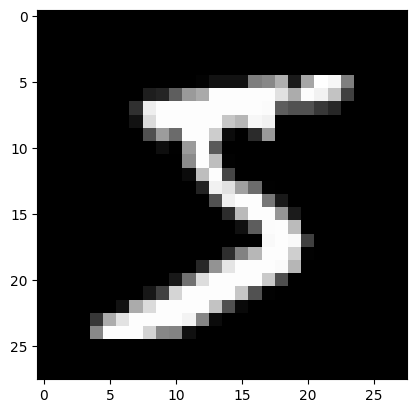

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

x_train0,y_train0=train_dataset[0]

print("Image shape", x_train0.shape) #images are stored as 3D data, where the first axis corresponds to the number of channels (here 1 as RGB images)
plt.imshow(x_train0.reshape(28,28,1), cmap='gray', interpolation="nearest") #plt.imshow require channels last, so we need to drop the channels
print("Target value",y_train0)

x_train0=x_train0.reshape(1,1,28,28) # we reshape the sample, as if it would be part of a batch of size 1
print("Batched x_train0 shape",x_train0.shape) #from now one, the first axes corresponds to the index of the sample in the batch

y_train0=torch.tensor(y_train0,dtype=torch.int32).reshape(1,1) # we do the same for y_train0 and we insist on the fact that the label is an integer
print("Batched y_train0 shape",y_train0.shape)

Let us define some constants that we be useful in the sequel

In [3]:
n = len(train_dataset)
d_x = x_train0.shape[1]
print(n,d_x)

60000 1


We can now begin to build the CNN. Following the explanations in the preamble, it seems like we need to turn the arrays of the dataset into `Tensor` instances. That won't be explicitely necessary because `PyTorch` will do that on its own. So we can readily define a first convoluational layer that we will connect to the batches array `x_train`. 

A second point to mention is that we will use high level functions in this practical session, i.e. functions that in reality translate in multiple nodes of the graph. These classes and functions are accessible through `torch.nn` and `torch.nn.Functional`, respectively. We will see that building a model follows the same philosophy of piling up operations.

One can define individual layers that are then aggregated together in order to construct the end to end model.

The usual layers (with default parameters) that are used in basic CNN architectures are : 
- convolutional layers : `torch.nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=1, padding=0, strides=1, bias=True)`
- activation functions : `torch.nn.Relu`, `torch.nn.Sigmoid`, `torch.nn.SofMax(dim)`
- pooling layers : `torch.nn.MaxPool2d(kernel_size=kernel_size, stride=kernel_size, padding=0)`, `torch.nn.AdaptativeMaxPool2d(output_size)` (or the corresponding `AvgPool2d`, `AdaptativeAvgPool2d` layers)
- flatting layers : `torch.nn.Flatten`
- the glue : `torch.nn.Sequential`


Start by creating one convolution layer (`conv1=torch.nn.Conv2d(...)`) with 64 filters (`out_channels`) of size 3 (`kernel_size`) applied with a stride of one. As the `conv1` is fed with the input data (grayscale image) the value of `in_channels` equals 1. For an RGB input, the `in_channels` should be 3.


In [3]:
import torch.nn as nn
conv1=nn.Conv2d(in_channels=1 ,out_channels=64, kernel_size=3)
print(conv1)

Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))


### Q1 

The `conv1` has set of weights (`conv1.weight`) and biaises (if `bias=True` was set in the constructor; otherwise, `conv1.bias is None`).

How many parameters `conv1.weight` and `conv1.bias` will be learned in this convolution layer ?

Check if you were right using `conv1.weight.numel()` and `conv1.bias.numel()` (if `conv1.bias` is not None).

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">
conv1.weight should learn $64 \times 3 \times 3 = 576$ parameters

conv1.bias should learn 64 parameters representing one by filter.

In [11]:
print(f"the number of weight learned is {conv1.weight.numel()}")
print(f"the number of bias learned is {conv1.bias.numel()}")

the number of weight learned is 576
the number of bias learned is 64


What will be the size of the feature map obtained by applying this convolution to the first image of the training set (`x_train0`) ? 

Apply the convolution layer to the first image of the training set (`conv1(x_train0)`) and checkout the obtained featuremap size.

Does this meet your expectations ?

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

I expect to obtain a feature map of size $64 \times 26 \times 26$

In [6]:
fm0= conv1(x_train0)
print(fm0.shape)

torch.Size([1, 64, 26, 26])


<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">
The result is what I expected

Next, we need a pooling layer to give up some entries of the filtered images provided by the convolutional layer. We will use the usual max pool function `torch.nn.MaxPool2d` in 2x2 neighborhoods which drops 3 entries out of 4 in each such neighborhood. The remaining entry is the one achieving maximal value in the neighborhood.

In [7]:
pool1=nn.MaxPool2d(kernel_size=2,stride=2)

### Q2
* Why is `stride=2` the correct parameter value for our goal ?
  
* What will be the size of the feature map obtained by applying the pooling layer to the feature map obtained after conv1 applied to the first image of the training set (`x_train0`) ? 

* Write the code that pools over the `fm0` using `pool1` and check the size and the number of feature maps obtained (`pooled_fm0`) after pooling. Check the obtained featuremap size.

* Does this meet your expectations ? 

* How many training parameters are present here ?


<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">
    
*  `stride=2` is the correct parameter since we need a pool function in $2\times2$ neighborhoods then the stride has a shape of `(2,2)` 
*  We will obtain a $64\times13\times13$ feature map after appyling the max pooling function

In [8]:
pooled_fm0= pool1(fm0)
print(pooled_fm0.shape)

torch.Size([1, 64, 13, 13])


<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">
    
* My expectations are correct
* Then the number of parameters is 10816

We will now plug a 1-layer-MLP on top of this. Fully connected layers (or dense layers) only accept 1D tensor (in a case only one input data is presented) or 2D tensors (if a batch (a series) of input data are presented). 

We can use the `nn.Flatten` layer or directly reshape (using `.view(NEW_SHAPE)` very fast if tensor is contiguous in memory or `.reshape(NEW_SHAPE)` slower but works even if tensor is not contiguous in memory).


### Q3
In the following code the scalar `dflat` as the nbr of feature maps x feature map width x feature map height. 

Does the size of the `fm0_pooled_flat` corresponds to  `dflat`?

In [9]:
dflat = pooled_fm0.shape[1] * pooled_fm0.shape[2] * pooled_fm0.shape[3]

flatten=nn.Flatten(start_dim=1) #we do not want to flatten also the batch as a whole, so we start at the second axis (=1)
flat_pooled_fm0 = flatten(pooled_fm0)
print(flat_pooled_fm0.shape[1]==dflat)

True


<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

The size of `fm0_pooled_flat` corresponds to `dflat` since `fm0_pooled_flat` has a `(1,10816)` shape and `dflat` has a (10816,) shape.

### Q4

Now the first layer MLP is given by an instance of `torch.nn.Linear` as:

In [10]:
mlp = nn.Linear(in_features=dflat,out_features=10)

The output of the MLP layer can be seen as __logits__ `mlp(fm0_pooled_flat)`.

* Checkout the shape of `logits` ?

* Is it coherent with your expectations ?

* How many training parameters are present here ?

In [18]:
logits0= mlp(flat_pooled_fm0)

print(logits0.shape,mlp.weight.numel(),mlp.bias.numel())

torch.Size([1, 10]) 108160 10


<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

* The shape of logits is coherent since the MNIST dataset is composed of 10 different digits corresponding to the classes.
* Here we have 108160 parameters to train.

`logits0` corresponds to the logits computed for the first sample of the training set after the sample has been forwarded through a `Conv2d`, a `MaxPool2d`, a `Flatten` and a `Linear` layer.

Write the code that print outs the `logits0` output and decide of the predicted number.

In [19]:
print("logits : ", logits0)
print("predicted class : ", logits0.numel())

logits :  tensor([[ 0.1804,  0.0576, -0.0278, -0.1451,  0.0931, -0.0229, -0.0054, -0.0228,
          0.1120,  0.0174]], grad_fn=<AddmmBackward0>)
predicted class :  10


### Q6 

Now, we can try to compute the loss for the first sample.

We need to prepare the target (y_train0) such that it can matches the `logits0` shape. Indeed the `loss` function, will try to measure how close the `logits0` were from the ideal situation : all `logits0` elements except for the one that corresponds to the target are 0, and the target associated one is 1.

If y_train0[0] == 5, we would expect an ideal `logits0` that looks like `[0]*4 + [1] + [0]*5`. Note : (y_train0[0] allows us to access the first target in the batch).

Construct a `torch.tensor` `y_train0_onehot` that reflects the desired `logits0` for predicted undoubtfully the value of `y_train0`. We call this encoding __a one hot encoding__ as only one value is hot (the one that equals 1), the others equals 0. We will associate to the newly created tensor the same `dtype` as the one of the `logits`.

Before being able to apply the loss computation `loss(logits0,y_train0_onehot)`, do not forget to reshape the `y_train0_onehot` in order to match the shape of a batch input of size one (1,10) - 1 for the number of samples in the batch and 10 for the number of `logits0`.

You may observe situations where the prediction is good, but it was not done based on an `logits0` that reflects the __one hot encoding__. In such cases, the loss is not null.

To do so, we can instanciate a `torch.nn.CrossEntropyLoss` instance (`loss`).
When using it in a classical batch training process the construction of the __one hot encoding__ is not required.

**NOTE**: Another specificity of `torch.nn.CrossEntropyLoss` is that it encompasses a `Softmax` activation function and the `NLLLoss`. So you should not add any activation functions before the `CrossEntropyLoss`!


In [20]:
loss=nn.CrossEntropyLoss()

print(y_train0)
y_train0_onehot = torch.zeros(10, dtype=logits0.dtype)
y_train0_onehot[y_train0[0][0] - 1] = 1.0
y_train0_onehot = y_train0_onehot.reshape(logits0.shape)
loss(logits0,y_train0_onehot)

tensor([[5]], dtype=torch.int32)


tensor(2.2368, grad_fn=<DivBackward1>)

We can now bring all the pieces together in a `torch.nn.Sequential` layer.

We can have an overview of the model by printing it.

In [12]:
model=torch.nn.Sequential(conv1, pool1, flatten, mlp)
print(model)
print(model(x_train0))

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (2): Flatten(start_dim=1, end_dim=-1)
  (3): Linear(in_features=10816, out_features=10, bias=True)
)
tensor([[ 0.1804,  0.0576, -0.0278, -0.1451,  0.0931, -0.0229, -0.0054, -0.0228,
          0.1120,  0.0174]], grad_fn=<AddmmBackward0>)


We can also ask more details about the shapes and the number of parameters in each layer using `torchsummary.summary`.
The `summary` function requires both the model and the expected input size.

In [13]:
from torchsummary import summary
summary(model,(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
         MaxPool2d-2           [-1, 64, 13, 13]               0
           Flatten-3                [-1, 10816]               0
            Linear-4                   [-1, 10]         108,170
Total params: 108,810
Trainable params: 108,810
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.50
Params size (MB): 0.42
Estimated Total Size (MB): 0.91
----------------------------------------------------------------


### Q7

Now lets suppose that the MNIST was encoded in RGB format, meaning that the input has a shape of (3,28,28).

* Do we need to create a complete new model or we can reuse some parts of the previous one ?

* How many parameters would require the model if the MNIST dataset was RGB like ?

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

* To create a model for a RGB format, We just have to create a new 2D Convolution layer by setting the in_channels parameter to 3 instead of 1. All the other parts don't need to be modified
* This new model will require $\text{nb of Conv2d parameters} \times \text{nb of Linear parameters}$   

In [49]:
conv2=nn.Conv2d(in_channels=3 ,out_channels=64, kernel_size=3)
modelRGB=torch.nn.Sequential(conv2, pool1, flatten, mlp)
summary(modelRGB,(3,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]           1,792
         MaxPool2d-2           [-1, 64, 13, 13]               0
           Flatten-3                [-1, 10816]               0
            Linear-4                   [-1, 10]         108,170
Total params: 109,962
Trainable params: 109,962
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.50
Params size (MB): 0.42
Estimated Total Size (MB): 0.92
----------------------------------------------------------------


Let's comme back to the initial model (the one that considers grayscale encodings (1,28,28)).

We can forward the input `x_train0` through the entire model and compute the loss between the `logits0` output and the __one hot encoded__ `y_train0_onehot`.

In [50]:
logits=model(x_train0)
loss_value=loss(logits0,y_train0_onehot)
print("Loss: ",loss_value.item()) #the .item() function returns the float value and not the related tensor (used for backprop)

Loss:  2.0797321796417236


We are almost done ... 

The gradient computation and the update of the parameters can be done automatically by pytorch by using an optimizer.

Let's use `torch.optim.Adam` with a `lr` of 1e-3.

In [76]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


After intializing the optimizer, one can compute forward the input batch through the network, compute the loss (`loss_value`), backpropagate the loss derivative through the network (`.backward()`) and then ask the optimizer to update the parameters (`step()`).

In the example, bellow we make a copy of the conv1.weights before the backpropagation and after the backpropagation. The `.detach()` functions ask the optimizer not to track operations done on `_tmp1` and `_tmp2` tensor as they are not part of the training.

In [52]:
optimizer.zero_grad() # we are presenting a new sample, so we want to forget what happened for the previous one

logits=model(x_train0)
loss_value=loss(logits,y_train0_onehot)

_tmp1=conv1.weight.clone()
_tmp1.detach()
loss_value.backward()
optimizer.step()
_tmp2=conv1.weight.clone()
_tmp2.detach()

print(torch.min(_tmp1-_tmp2),torch.max(_tmp1-_tmp2)) #check if the gradient update impacted conv1.weight

tensor(-0.0010, grad_fn=<MinBackward1>) tensor(0.0010, grad_fn=<MaxBackward1>)


We need now to prepare the data for training the model.
We will use a `torch.utils.data.DataLoader` for that.


In [14]:
from torch.utils.data import DataLoader

batch_size=64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # Shuffle the data for training
)

Once the `train_loader` is created, we can iterate over the batches in order to train the model.

### Q8
Replace the comments with the corresponding instructions.

In [15]:
def train_one_epoch(model, train_loader, loss, optimizer, verbose=True):
    running_loss=0
    model.train() #we inform that model that we switch to the training phase
    for i,(images,labels) in enumerate(train_loader):
        optimizer.zero_grad()
        #forward the input data
        logits = model(images)
        #compute the loss value
        loss_value = loss(logits, labels)
        #backpropagate the gradient
        loss_value.backward()
        #ask the optimizer to update the parameters
        optimizer.step()
        #one can compute a running loss over batches and print it out from time to time
        running_loss=running_loss*0.9+loss_value.item()*0.1 #here we use .item() to access directly the float value of the tensor
        if verbose and (i%100==0):
            print("Batch %d loss %.4f running_loss %.4f"%(i,loss_value,running_loss))
            
    print("Current epoch running_loss %.4f"%running_loss)

Run the training for an epoch

In [79]:
train_one_epoch(model, train_loader, loss, optimizer)

Batch 0 loss 1.0234 running_loss 0.1023
Batch 100 loss 0.0592 running_loss 0.0783
Batch 200 loss 0.0078 running_loss 0.0781
Batch 300 loss 0.0132 running_loss 0.0475
Batch 400 loss 0.0287 running_loss 0.0583
Batch 500 loss 0.1789 running_loss 0.0920
Batch 600 loss 0.0264 running_loss 0.0554
Batch 700 loss 0.0018 running_loss 0.0560
Batch 800 loss 0.0237 running_loss 0.0583
Batch 900 loss 0.0124 running_loss 0.0728
Current epoch running_loss 0.0620


<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

As we can see, the loss is decreasing over epochs meaning that we have at the end a probability $>95$% to get the right prediction

Now we will evaluate the model in terms of accuracy. During the evaluation, one should skip computing gradients (use `with torch.no_grad:` within the function or `@torch.no_grad` annotation right above the function declaration) 

In [21]:
#@torch.no_grad
def evaluate(model, loader, loss):
    model.eval() # switch the model in eval mode
    cummulated_loss=0
    correct_predictions=0
    total=0
    
    with torch.no_grad():
        for images,labels in loader:
            #forward the input data
            logits = model(images)
            #aggregate the loss value (use the .item() here as we do not have grads anyway)
            cummulated_loss += loss(logits, labels).item()
            
            #aggregate the correct predictions (compare the indices of the max output with 
            #                                   the labels and then sum up boolean values, 
            #                                   use also the .item() not to aggregate tensors)
            
            idx = logits.argmax(dim=1)
            comp = (idx == labels)
            correct_predictions += comp.sum().item()
            total=total+images.shape[0]
        
    mean_loss = cummulated_loss/len(loader) #the loss is averaged over the batches
    accuracy = correct_predictions/total
    return mean_loss,accuracy
        
evaluate(model,train_loader,loss)

(2.307313286419362, 0.07361666666666666)

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

* We obtained a mean loss of 0.07, which indicates that the model has converged well.
* The achieved accuracy of 97% shows that the model makes reliable predictions.

### Q9

Run the model for several epochs (3 to 5) and evaluate the model after each epoch.
What do you observe ?

In [63]:
for epoch in range(5):
    train_one_epoch(model, train_loader, loss, optimizer)
    loss_epoch,acc_epoch=evaluate(model,train_loader,loss)
    print("Epoch : %d Loss : %.4f Accuracy : %.4f"%(epoch,loss_epoch,acc_epoch))

Batch 0 loss 0.0901 running_loss 0.0090
Batch 100 loss 0.0477 running_loss 0.0883
Batch 200 loss 0.0363 running_loss 0.0762
Batch 300 loss 0.1163 running_loss 0.1128
Batch 400 loss 0.1089 running_loss 0.0832
Batch 500 loss 0.0617 running_loss 0.0842
Batch 600 loss 0.0898 running_loss 0.0621
Batch 700 loss 0.0228 running_loss 0.0882
Batch 800 loss 0.1679 running_loss 0.0808
Batch 900 loss 0.0120 running_loss 0.0851
Current epoch running_loss 0.0878
Epoch : 0 Loss : 0.0670 Accuracy : 0.9801
Batch 0 loss 0.0503 running_loss 0.0050
Batch 100 loss 0.0392 running_loss 0.0626
Batch 200 loss 0.0165 running_loss 0.0697
Batch 300 loss 0.1233 running_loss 0.0512
Batch 400 loss 0.0137 running_loss 0.0645
Batch 500 loss 0.1033 running_loss 0.0765
Batch 600 loss 0.1141 running_loss 0.0655
Batch 700 loss 0.0443 running_loss 0.0618
Batch 800 loss 0.0270 running_loss 0.0619
Batch 900 loss 0.0734 running_loss 0.0607
Current epoch running_loss 0.0638
Epoch : 1 Loss : 0.0585 Accuracy : 0.9823
Batch 0 loss

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

After running the model for 5 epochs and evaluate it after each epoch, we observe that the loss decreases which what we expect.

Furthermore, after the first epoch, the accuracy increases rapidly since we got an accuracy of 98%. Then, it goes to 98% at epoch 98% to 99% at epoch 4.

### Q10
Create a new model (having the same structure : conv + pool + flatten + linear) by adding (nn.ReLU) activation function between appropriate layers.


In [71]:
relu = nn.ReLU()

model=torch.nn.Sequential(conv1, relu, pool1, flatten, mlp)

#reinitialise all the parameters of the layers that have trained parameters in the model
for layer in model:
    if hasattr(layer, 'reset_parameters'):
        layer.reset_parameters()

for epoch in range(6):
    train_one_epoch(model, train_loader, loss, optimizer)
    loss_epoch,acc_epoch=evaluate(model, train_loader, loss)
    print("Epoch : %d Loss : %.4f Accuracy : %.4f"%(epoch,loss_epoch,acc_epoch))


Batch 0 loss 2.3639 running_loss 0.2364
Batch 100 loss 0.2145 running_loss 0.2913
Batch 200 loss 0.2650 running_loss 0.2325
Batch 300 loss 0.1392 running_loss 0.1951
Batch 400 loss 0.0776 running_loss 0.1565
Batch 500 loss 0.0916 running_loss 0.1115
Batch 600 loss 0.1059 running_loss 0.1183
Batch 700 loss 0.1735 running_loss 0.1038
Batch 800 loss 0.2135 running_loss 0.1131
Batch 900 loss 0.1126 running_loss 0.1257
Current epoch running_loss 0.1085
Epoch : 0 Loss : 0.0857 Accuracy : 0.9767
Batch 0 loss 0.0723 running_loss 0.0072
Batch 100 loss 0.1858 running_loss 0.0829
Batch 200 loss 0.0649 running_loss 0.0821
Batch 300 loss 0.1468 running_loss 0.0779
Batch 400 loss 0.0861 running_loss 0.0724
Batch 500 loss 0.0909 running_loss 0.0811
Batch 600 loss 0.0363 running_loss 0.0632
Batch 700 loss 0.1807 running_loss 0.0822
Batch 800 loss 0.0578 running_loss 0.0609
Batch 900 loss 0.0881 running_loss 0.0548
Current epoch running_loss 0.0551
Epoch : 1 Loss : 0.0576 Accuracy : 0.9834
Batch 0 loss

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

We observe that the accuracy keep increasing over the epochs with the ReLU activation function which add a non-linearity to the network to get a better precision.

### Q11

To check that we did not overfit, we need to evaluate our model on the test set.

Create a test loader and launch the evaluate procedure on the test set.

Comment on the results


In [72]:
batch_size=64

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
)

loss_test,acc_test=evaluate(model,test_loader,loss)

print("Test set Loss : %.4f Accuracy : %.4f"%(loss_test,acc_test))


Test set Loss : 0.0530 Accuracy : 0.9845


<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

Evaluation on the test set shows a loss of 0.0530 and an accuracy of 98.45%. The small gap with the training metrics indicates that the model did not overfit and predicted well.

### Q12
* Add a second pair of conv/pool layers. A smaller amount amount of filters and smaller filters are recommended.

### Q13
* Add a second fully connected layer. A smaller number of units is recommended.

### Q14
* Add a second fully connected layer. A smaller number of units is recommended.


### Q15
From the above NN architecture, try to tweak the other hyperparameters. These latter include:
* the learning rate,
* number of filters,
* filter sizes,
* activiation functions,
* strides,
* padding types,
* ...

### Q16
* Compare the obtained accuracy to that of a regularized Softmax regression from `sklearn`.

### Q12

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

* For the second 2D convolution, we know the first one give 64 channels as output thus we must set the `in_channels` parameter to 64 as well. I've chose 32 as 'out_channels` in order to reduce the amount of filters.

* I have set the same max pooling 2x2 function with the same kernel_size and stride as the first one 

In [25]:
conv2 = nn.Conv2d(in_channels=64 ,out_channels=32, kernel_size=3)
pool2 = nn.MaxPool2d(kernel_size=2,stride=2)
relu = nn.ReLU()

### Q13

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

* By applying `nn.Flatten` at this level of the network, we will have $32\times5\times5 = 800$ features and we want as outputs, 64 units.
* Finally, we add our final fully connected layer to our network which has as input 64 units and will give 10 units representing the MINST classes. 

In [26]:
mlp1 = nn.Linear(in_features=800,out_features=64)
mlp2 = nn.Linear(in_features=64,out_features=10)

### Q15

In [27]:
model=torch.nn.Sequential(conv1, relu, pool1, conv2, relu, pool2, flatten, mlp1, mlp2)
summary(model,(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
              ReLU-2           [-1, 64, 26, 26]               0
         MaxPool2d-3           [-1, 64, 13, 13]               0
            Conv2d-4           [-1, 32, 11, 11]          18,464
              ReLU-5           [-1, 32, 11, 11]               0
         MaxPool2d-6             [-1, 32, 5, 5]               0
           Flatten-7                  [-1, 800]               0
            Linear-8                   [-1, 64]          51,264
            Linear-9                   [-1, 10]             650
Total params: 71,018
Trainable params: 71,018
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.81
Params size (MB): 0.27
Estimated Total Size (MB): 1.09
---------------------------------------------

In [31]:
#Testing with different learning rate
learning_rates = [1, 1e-3, 1e-7]
for lr in learning_rates:

    for layer in model:
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_epochs = []
    acc_epochs = []
    
    for epoch in range(3):
        train_one_epoch(model, train_loader, loss, optimizer, verbose=False)
        loss_epoch,acc_epoch=evaluate(model,train_loader,loss)

        loss_epochs.append(loss_epoch)
        acc_epochs.append(acc_epoch)

    print(rf'NN Mertics with learning rate$\eta = {lr}$:')
    print(f"Mean loss per epochs : {loss_epochs}")
    print(f"accuracy per epochs : {acc_epochs}")


Current epoch running_loss 29.3593
Current epoch running_loss 26.4380
Current epoch running_loss 21.3757
NN Mertics with learning rate$\eta = 1$:
Mean loss per epochs : [19.941312448302313, 13.572763147638804, 32.99568120604639]
accuracy per epochs : [0.09751666666666667, 0.09915, 0.09035]
Current epoch running_loss 0.0822
Current epoch running_loss 0.0474
Current epoch running_loss 0.0275
NN Mertics with learning rate$\eta = 0.001$:
Mean loss per epochs : [0.06876987374342008, 0.050048328533238456, 0.04359357257503699]
accuracy per epochs : [0.9790833333333333, 0.9845166666666667, 0.9860833333333333]
Current epoch running_loss 2.3027
Current epoch running_loss 2.3053
Current epoch running_loss 2.2943
NN Mertics with learning rate$\eta = 1e-07$:
Mean loss per epochs : [2.3049736899861903, 2.302483916791009, 2.3000090045969626]
accuracy per epochs : [0.0972, 0.0976, 0.09825]


<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

The experiments show that the learning rate has a strong impact on training. With a very large learning rate (η = 1), the training is unstable, leading to high losses and an accuracy close to 10%. With a very small learning rate (η = 10⁻⁷), the loss remains around 2.30 and the accuracy stays near 10%, indicating that the model doesn't learn. However, a learning rate of η = 10⁻³ provides stable convergence, which indicates an effective learning. 

In [33]:
#Testing with a different activation function
sigmoid = nn.Sigmoid()
model = nn.Sequential(conv1, sigmoid, pool1, conv2, sigmoid, pool2, flatten, mlp1, mlp2)
summary(model,(1,28,28))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
for epoch in range(4):
    train_one_epoch(model, train_loader, loss, optimizer, verbose=False)
    loss_epoch,acc_epoch=evaluate(model,train_loader,loss)
    print("Epoch : %d Loss : %.4f Accuracy : %.4f"%(epoch,loss_epoch,acc_epoch))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
           Sigmoid-2           [-1, 64, 26, 26]               0
         MaxPool2d-3           [-1, 64, 13, 13]               0
            Conv2d-4           [-1, 32, 11, 11]          18,464
           Sigmoid-5           [-1, 32, 11, 11]               0
         MaxPool2d-6             [-1, 32, 5, 5]               0
           Flatten-7                  [-1, 800]               0
            Linear-8                   [-1, 64]          51,264
            Linear-9                   [-1, 10]             650
Total params: 71,018
Trainable params: 71,018
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.81
Params size (MB): 0.27
Estimated Total Size (MB): 1.09
---------------------------------------------

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">
    
When we use the sigmoid activation function, we didn't notice a huge modification on the convergence compared to the ReLU activation function.

### Q17

General comments:

<div style="background-color:#e6ffe6; border-left:5px solid green; padding:10px;">

* To conclude this lab, I learned especially how a neural network can be implemented by combining convolution, pooling, different activation function and so on and so far. I understand better how the features maps are created over each step of the deep architecture.

* I can add that this kind of algorithms are heavy on computation. Hence, choosing the right number of filters or finding the best size for these filters is an important part of the reflexion to create a effective neural network